In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

import numpy as np
import matplotlib.pyplot as plt
import functions
import bilby
import seaborn as sns
import pandas as pd
from pprint import pprint

In [2]:
sns.set_theme(context="talk", palette="husl", style="whitegrid")
palette = sns.color_palette("husl")

In [3]:
# ---------------------------
# Priors
# ---------------------------
priors = bilby.core.prior.PriorDict()
priors['mass_1'] = bilby.core.prior.analytical.PowerLaw(minimum=5, maximum=50, alpha=-2.3,
                                                        name='mass_1')
priors['a_1'] = bilby.core.prior.Uniform(name='a_1', minimum=0, maximum=0.1)
priors['tilt_1'] = bilby.core.prior.analytical.Sine(name='tilt_1')
priors['tilt_2'] = bilby.core.prior.analytical.Sine(name='tilt_2')
priors['phi_12'] = bilby.core.prior.Uniform(name='phi_12', minimum=0,
                                            maximum=2 * np.pi, boundary='periodic')
priors['phi_jl'] = bilby.core.prior.Uniform(name='phi_jl', minimum=0,
                                            maximum=2 * np.pi, boundary='periodic')
priors['phase'] = bilby.core.prior.Uniform(name='phase', minimum=0,
                                           maximum=2 * np.pi, boundary='periodic')
priors['theta_jn'] = bilby.core.prior.analytical.Sine(minimum=75 / 180 * np.pi,
                                                      maximum=105 / 180 * np.pi,
                                                      name='theta_jn')
print("Priors used for 1G population:")
pprint(priors)

Priors used for 1G population:
{'a_1': Uniform(minimum=0, maximum=0.1, name='a_1', latex_label='$a_1$', unit=None, boundary=None),
 'mass_1': PowerLaw(alpha=-2.3, minimum=5, maximum=50, name='mass_1', latex_label='$m_1$', unit=None, boundary=None),
 'phase': Uniform(minimum=0, maximum=6.283185307179586, name='phase', latex_label='$\\phi$', unit=None, boundary='periodic'),
 'phi_12': Uniform(minimum=0, maximum=6.283185307179586, name='phi_12', latex_label='$\\Delta\\phi$', unit=None, boundary='periodic'),
 'phi_jl': Uniform(minimum=0, maximum=6.283185307179586, name='phi_jl', latex_label='$\\phi_{JL}$', unit=None, boundary='periodic'),
 'theta_jn': Sine(minimum=1.3089969389957472, maximum=1.8325957145940461, name='theta_jn', latex_label='$\\theta_{JN}$', unit=None, boundary=None),
 'tilt_1': Sine(minimum=0, maximum=3.141592653589793, name='tilt_1', latex_label='$\\theta_1$', unit=None, boundary=None),
 'tilt_2': Sine(minimum=0, maximum=3.141592653589793, name='tilt_2', latex_label='$\\t

In [4]:
def n1gn2g_merger(population, priors, N_to_merge_1, N_to_merge_2):
    # pick the first black hole from the population with N_merge = N_to_merge_1
    mask1 = population["N_merge"] == N_to_merge_1
    population1 = population[mask1]

    if len(population1) == 0:
        raise ValueError(f"No black holes with N_merge = {N_to_merge_1} left to merge.")

    # sample the first black hole
    random_bh1 = population1.sample(n=1)

    # pick the second black hole from the population with N_merge = N_to_merge_2
    # need to make sure that if N_to_merge_1 == N_to_merge_2, we don't pick the same black hole
    temp_population = population.drop(random_bh1.index)
    mask2 = temp_population["N_merge"] == N_to_merge_2
    population2 = temp_population[mask2]

    if len(population2) == 0:
        raise ValueError(f"No black holes with N_merge = {N_to_merge_2} left to merge.")

    # sample the second black hole
    random_bh2 = population2.sample(n=1)

    # create a new dataframe without the sampled rows
    # we already removed the first black hole from temp_population
    new_pop = temp_population.drop(random_bh2.index)

    # reset the indices
    random_bh1 = random_bh1.reset_index(drop=True)
    random_bh2 = random_bh2.reset_index(drop=True)
    new_pop = new_pop.reset_index(drop=True)

    # extract properties of the two black holes
    mass_1 = float(random_bh1.at[0, 'mass_1'])
    a_1 = float(random_bh1.at[0, 'a_1'])
    tilt_1 = float(random_bh1.at[0, 'tilt_1'])
    phi_12 = float(random_bh1.at[0, 'phi_12'])
    mass_2 = float(random_bh2.at[0, 'mass_1'])
    a_2 = float(random_bh2.at[0, 'a_1'])
    tilt_2 = float(random_bh2.at[0, 'tilt_2'])

    # reorder by larger mass
    mass_1, mass_2, a_1, a_2, tilt_1, tilt_2 = functions.reorder_masses(
        mass_1, mass_2, a_1, a_2, tilt_1, tilt_2
    )
    
    # get the remnant properties
    final_mass, final_spin, final_kick = functions.get_remnant_properties(
        mass_1, mass_2, a_1, a_2, tilt_1, tilt_2, phi_12
    )

    # sample some new values from prior to use for tilts, phase, etc...
    new_params = priors.sample(1)
    
    # add the remnant to the new population
    new_row = {
        "mass_1": final_mass,
        "a_1": final_spin,
    
        # remnant-independent parameters
        "tilt_1": new_params["tilt_1"][0],
        "tilt_2": new_params["tilt_2"][0],
        "phi_12": new_params["phi_12"][0],
        "phi_jl": new_params["phi_jl"][0],
        "phase": new_params["phase"][0],
        "theta_jn": new_params["theta_jn"][0],
    
        # set the N_merge and kick velocity
        "N_merge": random_bh1.at[0, 'N_merge'] + random_bh2.at[0, 'N_merge'] + 1,
        "kick": final_kick
    }

    new_pop.loc[len(new_pop)] = new_row

    merger_row = {
        "mass_1": mass_1,
        "mass_2": mass_2,
        "a_1": a_1,
        "a_2": a_2,
        "tilt_1": tilt_1,
        "tilt_2": tilt_2,
        "Ng": int(random_bh1.at[0, 'N_merge'] + random_bh2.at[0, 'N_merge'] + 1),
        "m_f": final_mass,
        "a_f": final_spin,
        "v_k": final_kick,
    }

    return new_pop, merger_row

In [5]:
N_initial = 30
N_branches = 100
N_merge_max = int(np.floor(np.log2(N_initial)))

populations = {}

# Create the initial population
populations[0] = functions.generate_initial_population(N_initial, priors)

In [8]:
masses1, spins1 = [], []
masses2, spins2 = [], []

for iterations in range(5000):
    case1, _ = n1gn2g_merger(populations[0], priors, 0, 0)
    case1, _ = n1gn2g_merger(case1, priors, 0, 0)
    case1, _ = n1gn2g_merger(case1, priors, 1, 1)
    
    case2, _ = n1gn2g_merger(populations[0], priors, 0, 0)
    case2, _ = n1gn2g_merger(case2, priors, 1, 0)
    case2, _ = n1gn2g_merger(case2, priors, 2, 0)
    
    masses1.append(case1.iloc[-1]['mass_1'])
    spins1.append(case1.iloc[-1]['a_1'])
    masses2.append(case2.iloc[-1]['mass_1'])
    spins2.append(case2.iloc[-1]['a_1'])

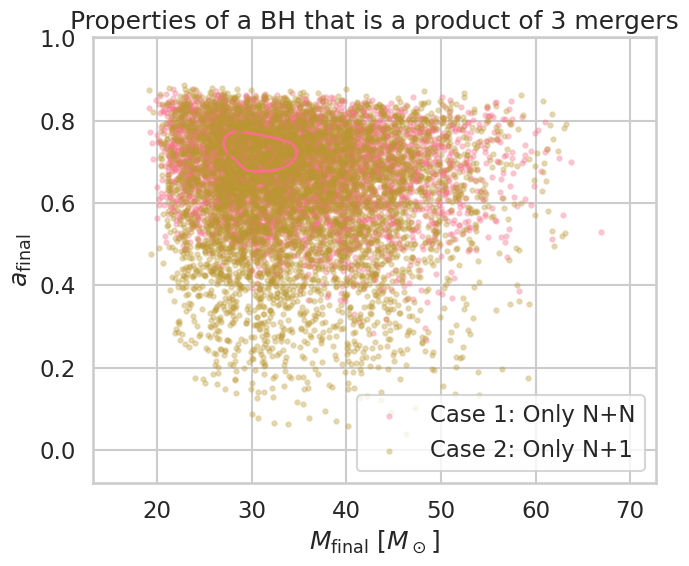

In [9]:
plt.figure(figsize=(7,6))

# Plot the samples
plt.scatter(masses1, spins1, color=palette[0], alpha=0.3, s=10, label='Case 1: Only N+N')
plt.scatter(masses2, spins2, color=palette[1], alpha=0.3, s=10, label='Case 2: Only N+initial')

# Add 90% credible contours
sns.kdeplot(x=masses1, y=spins1, levels=[0.9], color=palette[0], fill=False, linewidths=2)
sns.kdeplot(x=masses2, y=spins2, levels=[0.9], color=palette[1], fill=False, linewidths=2)

plt.xlabel(r'$M_{\mathrm{final}}$ [$M_\odot$]')
plt.ylabel(r'$a_{\mathrm{final}}$')
plt.title("Properties of a BH that is a product of 3 mergers")
plt.legend()
plt.tight_layout()
plt.show()